In [1]:
import os
import copy
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import MobileNet_V3_Large_Weights
from sklearn.metrics import classification_report, confusion_matrix

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {DEVICE}")



PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
Using: cuda


## 2. Configuration


In [2]:
DATASET_ROOT = Path(r"/kaggle/input/datasets/dukzf1v/data-dataa/Unified_DMS_Dataset_v4")
print(f"Dataset root: {DATASET_ROOT}")

# Verify folders exist
for split in ["train", "val", "test"]:
    p = DATASET_ROOT / split
    assert p.exists(), f"Missing: {p}"
    count = sum(
        len(list((p / c).glob("*.jpg")))
        for c in ["0_Neutral", "1_Anger", "2_Fear", "3_Happiness", "4_Sadness"]
    )
    print(f"  {split}: {count:,} images")

# ── Hyperparameters ────────────────────────────────────────────────────────
CFG = {
    "img_size":       224,
    "batch_size":     64,
    "num_workers":    4,
    "num_classes":    5,                        # [v3] 7-class full emotions
    # Phase 1 (backbone frozen)
    "lr_phase1":      3e-4,
    "weight_decay":   1e-4,
    "epochs":         40,
    "patience":       8,
    "unfreeze_after": 5,
    # Phase 2 (full fine-tuning)
    "lr_phase2":      5e-5,
    # LR scheduler
    "lr_factor":      0.5,
    "lr_patience":    3,
    "seed":           42,
    "output_dir":     "/kaggle/working" if Path("/kaggle/working").exists()
                      else str(Path(r"D:\StudyPath\Practice\advertising-system\output")),
    "class_names":    ["Neutral", "Anger", "Fear", "Happiness", "Sadness"],
}

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])



Dataset root: /kaggle/input/datasets/dukzf1v/data-dataa/Unified_DMS_Dataset_v4
  train: 46,306 images
  val: 11,580 images
  test: 17,271 images


## 3. Data Loading & Augmentation


In [3]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
SZ = CFG["img_size"]

train_tf = transforms.Compose([
    transforms.Resize((SZ + 32, SZ + 32)),
    transforms.RandomCrop(SZ),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=8),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.02),
    transforms.RandomGrayscale(p=0.05),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.02, scale=(0.01, 0.05)),
])

val_tf = transforms.Compose([
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_ds = datasets.ImageFolder(DATASET_ROOT / "train", transform=train_tf)
val_ds   = datasets.ImageFolder(DATASET_ROOT / "val",   transform=val_tf)
test_ds  = datasets.ImageFolder(DATASET_ROOT / "test",  transform=val_tf)

train_dl = DataLoader(train_ds, batch_size=CFG["batch_size"],
                      shuffle=True,  num_workers=CFG["num_workers"],
                      pin_memory=True, drop_last=True)
val_dl   = DataLoader(val_ds,   batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=CFG["num_workers"],
                      pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=CFG["batch_size"],
                      shuffle=False, num_workers=CFG["num_workers"],
                      pin_memory=True)

print(f"Train: {len(train_ds):,}  |  Val: {len(val_ds):,}  |  Test: {len(test_ds):,}")
print(f"Class index map: {train_ds.class_to_idx}")

# ── Class distribution & weights ──────────────────────────────────────────
counts = np.bincount(train_ds.targets)
print(f"Train class counts: {counts}")

# Inverse-frequency weighting
class_weights = torch.tensor(
    1.0 / counts / (1.0 / counts).sum() * CFG["num_classes"],
    dtype=torch.float32
).to(DEVICE)

print(f"Class weights: {class_weights.cpu().numpy().round(3)}")



Train: 46,306  |  Val: 11,580  |  Test: 17,271
Class index map: {'0_Neutral': 0, '1_Anger': 1, '2_Fear': 2, '3_Happiness': 3, '4_Sadness': 4}
Train class counts: [10247  8803  5108 13673  8475]
Class weights: [0.816 0.95  1.637 0.611 0.986]


## 4. Model: MobileNetV3-Large


In [4]:
def build_model(num_classes: int, dropout: float = 0.3) -> nn.Module:
    """MobileNetV3-Large with custom classifier head."""
    model = models.mobilenet_v3_large(weights=MobileNet_V3_Large_Weights.IMAGENET1K_V1)

    # Freeze backbone initially (Phase 1)
    for p in model.features.parameters():
        p.requires_grad_(False)

    # Replace classifier
    in_features = model.classifier[0].in_features
    model.classifier = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.Hardswish(),
        nn.Dropout(p=dropout),
        nn.Linear(256, num_classes),
    )
    return model


model = build_model(CFG["num_classes"]).to(DEVICE)

# Count parameters
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}  ({100*trainable/total:.1f}%)")



Downloading: "https://download.pytorch.org/models/mobilenet_v3_large-8738ca79.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_large-8738ca79.pth


100%|██████████| 21.1M/21.1M [00:00<00:00, 143MB/s] 


Total params:     3,219,253
Trainable params: 247,301  (7.7%)


## 5. Training Utilities


In [5]:
def make_optimizer(model, lr: float, weight_decay: float) -> optim.Optimizer:
    """AdamW optimizer over all currently trainable parameters."""
    return optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=weight_decay,
    )


def make_scheduler(optimizer) -> optim.lr_scheduler.ReduceLROnPlateau:
    """
    ReduceLROnPlateau scheduler — monitors val_acc (mode='max').

    FIX #1 & #2: Replaced OneCycleLR with ReduceLROnPlateau.
    Rationale:
      - OneCycleLR requires total_steps at construction time, which breaks
        when we re-create the optimizer/scheduler after unfreezing the backbone
        (re-creating resets the step counter, causing a ValueError on the next
        step call or producing a completely wrong LR schedule).
      - ReduceLROnPlateau is stateless w.r.t. total training length, so it is
        safe to construct fresh at any point during training without causing
        schedule discontinuities.
    """
    return optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",           # we track val_acc (higher = better)
        factor=CFG["lr_factor"],
        patience=CFG["lr_patience"],
    )


def unfreeze_backbone(model):
    """Unfreeze all backbone layers for Phase 2 fine-tuning."""
    for p in model.features.parameters():
        p.requires_grad_(True)
    total_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  [Unfreeze] Backbone unfrozen — trainable params: {total_trainable:,}")


def run_epoch(model, loader, criterion, optimizer=None):
    """Run one training or validation epoch."""
    training = optimizer is not None
    model.train() if training else model.eval()

    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            logits = model(imgs)
            loss   = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * len(labels)
            correct    += (logits.argmax(1) == labels).sum().item()
            n          += len(labels)

    return total_loss / n, correct / n



## 6. Training Loop


In [6]:
# ── Phase 1 setup (backbone frozen) ───────────────────────────────────────
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = make_optimizer(model, lr=CFG["lr_phase1"], weight_decay=CFG["weight_decay"])
scheduler = make_scheduler(optimizer)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc     = 0.0
patience_counter = 0
best_model_wts   = copy.deepcopy(model.state_dict())
phase            = 1   # track current training phase for logging

print("=" * 60)
print("Training MobileNetV3-Large  |  DMS 5-class Emotions")
print("=" * 60)

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    # ── Unfreeze backbone transition ──────────────────────────────────────
    if epoch == CFG["unfreeze_after"] + 1 and phase == 1:
        phase = 2
        print(f"\n{'─'*60}")
        print(f"  Epoch {epoch}: Switching to Phase 2 — Unfreezing backbone")
        unfreeze_backbone(model)

        # FIX #1 & #2: Re-create optimizer with lower LR for the full model.
        # Using ReduceLROnPlateau means we can safely build a fresh scheduler
        # here without any step-count mismatch.
        optimizer = make_optimizer(model, lr=CFG["lr_phase2"],
                                   weight_decay=CFG["weight_decay"])
        scheduler = make_scheduler(optimizer)

        # FIX #5: Reset patience counter and best_val_acc so that early
        # stopping and model-saving decisions are made relative to Phase 2
        # performance only. The label_smoothing change (0.1 → 0.05) shifts
        # the loss scale, making cross-phase loss/acc comparisons unreliable.
        best_val_acc     = 0.0
        patience_counter = 0
        best_model_wts   = copy.deepcopy(model.state_dict())

        # FIX #5 (continued): Tighten label smoothing for Phase 2.
        criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
        print(f"  Phase 2: lr={CFG['lr_phase2']:.1e}, label_smoothing=0.05")
        print(f"{'─'*60}\n")

    # ── Forward / backward pass ───────────────────────────────────────────
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer)
    vl_loss, vl_acc = run_epoch(model, val_dl,   criterion)

    # Step ReduceLROnPlateau once per epoch using val_acc
    scheduler.step(vl_acc)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    elapsed = time.time() - t0
    lr_now  = optimizer.param_groups[0]["lr"]
    marker  = " ★" if vl_acc > best_val_acc else ""

    print(f"[P{phase}|{epoch:02d}/{CFG['epochs']}] "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.4f} | "
          f"vl_loss={vl_loss:.4f} vl_acc={vl_acc:.4f} | "
          f"lr={lr_now:.2e} | {elapsed:.1f}s{marker}")

    # ── Checkpoint & early stopping ───────────────────────────────────────
    if vl_acc > best_val_acc:
        best_val_acc     = vl_acc
        patience_counter = 0
        best_model_wts   = copy.deepcopy(model.state_dict())
        torch.save({
            "epoch":        epoch,
            "phase":        phase,
            "model_state":  best_model_wts,
            "val_acc":      best_val_acc,
            "cfg":          CFG,
        }, f"{CFG['output_dir']}/best_mobilenetv3_5class.pth")
    else:
        patience_counter += 1
        if patience_counter >= CFG["patience"]:
            print(f"\nEarly stopping at epoch {epoch}  "
                  f"(best val_acc={best_val_acc:.4f}, phase={phase})")
            break

print(f"\nBest Val Acc: {best_val_acc:.4f}")



Training MobileNetV3-Large  |  DMS 5-class Emotions
[P1|01/40] tr_loss=1.4547 tr_acc=0.3977 | vl_loss=1.4510 vl_acc=0.4244 | lr=3.00e-04 | 220.1s ★
[P1|02/40] tr_loss=1.3847 tr_acc=0.4548 | vl_loss=1.4123 vl_acc=0.4506 | lr=3.00e-04 | 201.3s ★
[P1|03/40] tr_loss=1.3577 tr_acc=0.4761 | vl_loss=1.4065 vl_acc=0.4483 | lr=3.00e-04 | 189.5s
[P1|04/40] tr_loss=1.3350 tr_acc=0.4903 | vl_loss=1.3718 vl_acc=0.4800 | lr=3.00e-04 | 200.4s ★
[P1|05/40] tr_loss=1.3205 tr_acc=0.5012 | vl_loss=1.3724 vl_acc=0.4733 | lr=3.00e-04 | 179.6s

────────────────────────────────────────────────────────────
  Epoch 6: Switching to Phase 2 — Unfreezing backbone
  [Unfreeze] Backbone unfrozen — trainable params: 3,219,253
  Phase 2: lr=5.0e-05, label_smoothing=0.05
────────────────────────────────────────────────────────────

[P2|06/40] tr_loss=1.0903 tr_acc=0.6130 | vl_loss=1.0392 vl_acc=0.6370 | lr=5.00e-05 | 215.9s ★
[P2|07/40] tr_loss=0.9518 tr_acc=0.6920 | vl_loss=0.9219 vl_acc=0.7004 | lr=5.00e-05 | 198.8s

## 7. Training Curves


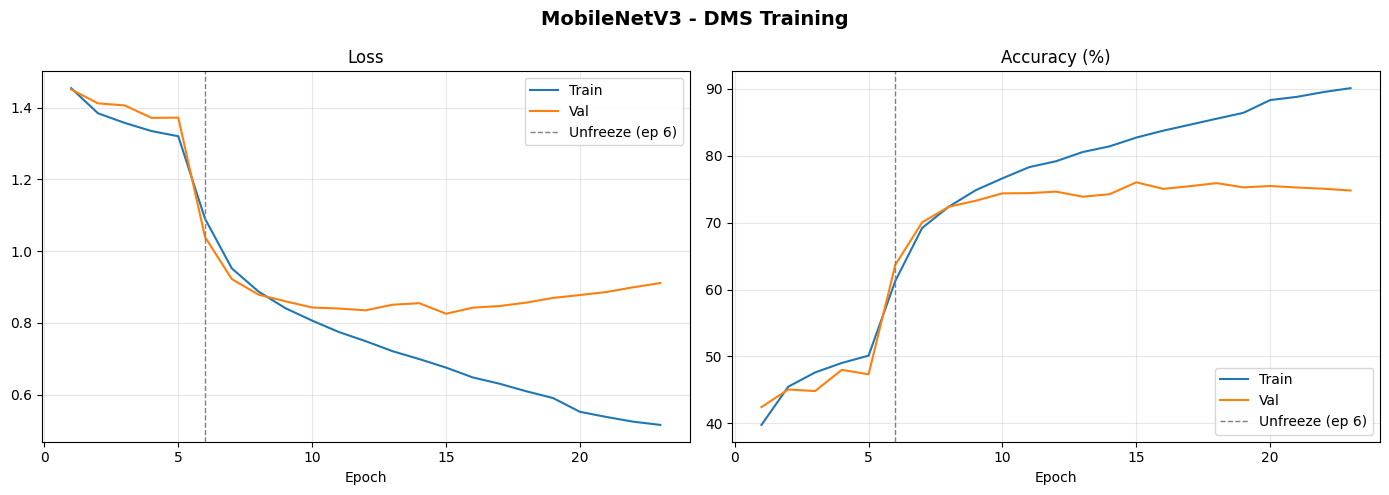

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
eps = range(1, len(history["train_loss"]) + 1)

# Draw a vertical line at the unfreeze epoch
unfreeze_ep = CFG["unfreeze_after"] + 1

axes[0].plot(eps, history["train_loss"], label="Train")
axes[0].plot(eps, history["val_loss"],   label="Val")
axes[0].axvline(unfreeze_ep, color="gray", linestyle="--",
                linewidth=1, label=f"Unfreeze (ep {unfreeze_ep})")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(eps, [a * 100 for a in history["train_acc"]], label="Train")
axes[1].plot(eps, [a * 100 for a in history["val_acc"]],   label="Val")
axes[1].axvline(unfreeze_ep, color="gray", linestyle="--",
                linewidth=1, label=f"Unfreeze (ep {unfreeze_ep})")
axes[1].set_title("Accuracy (%)")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("MobileNetV3 - DMS Training", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/training_curves.png", dpi=150)
plt.show()



## 8. Evaluation on Val & Test Sets


In [8]:
# Load best weights
model.load_state_dict(best_model_wts)
model.eval()


def evaluate(loader, split_name):
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc = (all_preds == all_labels).mean()

    print(f"\n{'='*55}")
    print(f"  {split_name} — Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print(f"{'='*55}")
    print(classification_report(
        all_labels, all_preds,
        target_names=CFG["class_names"]
    ))
    return all_labels, all_preds


val_labels,  val_preds  = evaluate(val_dl,  "VALIDATION SET")
test_labels, test_preds = evaluate(test_dl, "TEST SET (AFFECTNET)")




  VALIDATION SET — Accuracy: 0.7603 (76.03%)
              precision    recall  f1-score   support

     Neutral       0.73      0.80      0.76      2553
       Anger       0.70      0.71      0.71      2205
        Fear       0.65      0.61      0.63      1273
   Happiness       0.93      0.88      0.90      3422
     Sadness       0.66      0.66      0.66      2127

    accuracy                           0.76     11580
   macro avg       0.74      0.73      0.73     11580
weighted avg       0.76      0.76      0.76     11580


  TEST SET (AFFECTNET) — Accuracy: 0.7510 (75.10%)
              precision    recall  f1-score   support

     Neutral       0.75      0.88      0.81      3569
       Anger       0.76      0.65      0.70      3931
        Fear       0.70      0.59      0.64      2623
   Happiness       0.93      0.86      0.90      4432
     Sadness       0.55      0.70      0.62      2716

    accuracy                           0.75     17271
   macro avg       0.74      0.74

## 9. Confusion Matrices


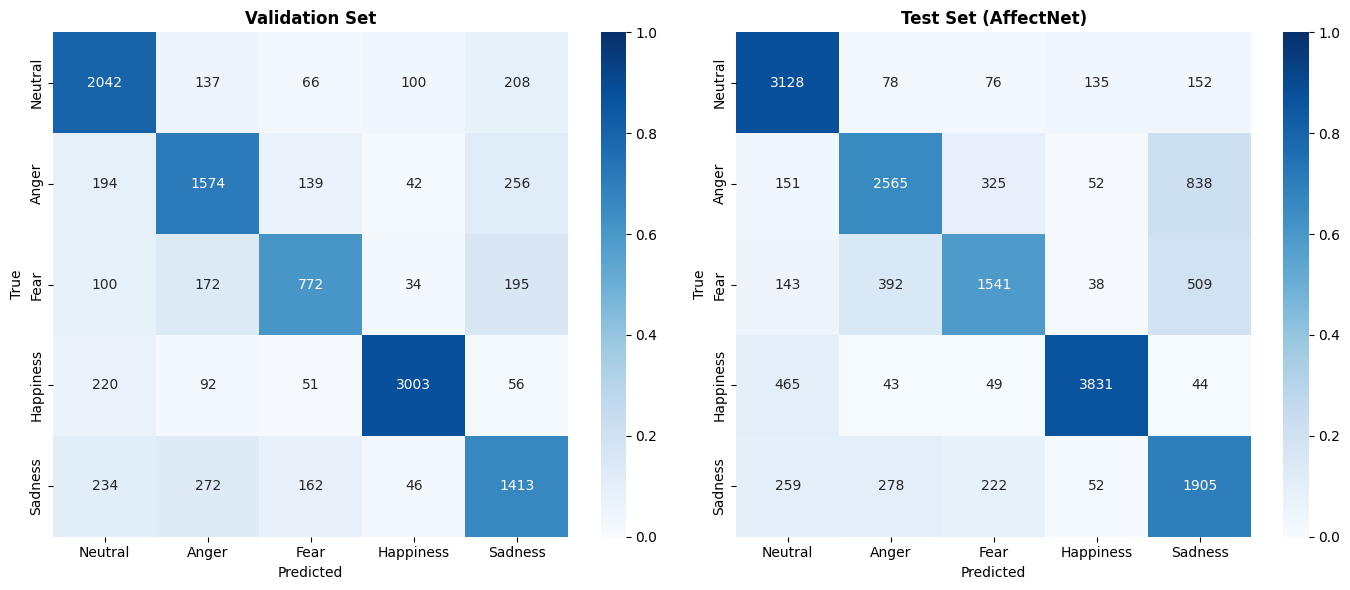

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (labels, preds, title) in zip(
    axes,
    [(val_labels,  val_preds,  "Validation Set"),
     (test_labels, test_preds, "Test Set (AffectNet)")],
):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(
        cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
        xticklabels=CFG["class_names"],
        yticklabels=CFG["class_names"],
        vmin=0, vmax=1,
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/confusion_matrices.png", dpi=150)
plt.show()



## 10. Export for Inference


In [10]:
# Save full model + metadata
torch.save({
    "model_state":  model.state_dict(),
    "class_names":  CFG["class_names"],
    "class_to_idx": train_ds.class_to_idx,
    "img_size":     CFG["img_size"],
    "mean":         IMAGENET_MEAN,
    "std":          IMAGENET_STD,
    "best_val_acc": best_val_acc,
    "cfg":          CFG,
}, f"{CFG['output_dir']}/mobilenetv3_5class_final.pth")

# Save training history as JSON
with open(f"{CFG['output_dir']}/history.json", "w") as f:
    json.dump(history, f, indent=2)

print("Saved:")
print(f"  {CFG['output_dir']}/best_mobilenetv3_5class.pth")
print(f"  {CFG['output_dir']}/mobilenetv3_5class_final.pth")
print(f"  {CFG['output_dir']}/history.json")
print(f"  {CFG['output_dir']}/training_curves.png")
print(f"  {CFG['output_dir']}/confusion_matrices.png")



Saved:
  /kaggle/working/best_mobilenetv3_5class.pth
  /kaggle/working/mobilenetv3_5class_final.pth
  /kaggle/working/history.json
  /kaggle/working/training_curves.png
  /kaggle/working/confusion_matrices.png


## 11. Quick Inference Test


In [11]:
from PIL import Image


def predict_image(image_path: str, model, device=DEVICE):
    img    = Image.open(image_path).convert("RGB")
    tensor = val_tf(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1).squeeze().cpu().numpy()
        pred   = probs.argmax()
    print(f"Predicted: {CFG['class_names'][pred]}  (conf={probs[pred]:.3f})")
    for name, p in zip(CFG["class_names"], probs):
        bar = "█" * int(p * 30)
        print(f"  {name:20s} {p:.4f}  {bar}")
    return pred, probs


# Example: predict_image("sample.jpg", model)
print("Model ready for inference.")
print(f"Best Val Accuracy: {best_val_acc*100:.2f}%")


Model ready for inference.
Best Val Accuracy: 76.03%
